<a href="https://colab.research.google.com/github/FatimaZulfiqar02/intro-ml-course-winter2025/blob/main/Datathon_2_Group_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1>Datathon #2</h1>

Group 4: Fatima Zulfiqar, Yalin Mu, Jaclyn Hearnden

Dataset #1: Mortality Dataset for Heart Failure Patients in Pakistan

In [ ]:
#Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

#Load the data
from google.colab import files
import io

uploaded = files.upload()

#Read the dataset into a Pandas DataFrame
df = pd.read_csv(io.BytesIO(uploaded['Datathon #2 Heart Failure Mortality.csv']))

#Display the first few rows of the dataset to ensure it's loaded correctly
df.head()

In [ ]:
#Test dropping time because it is different from other model variables in that it is not lifestyle, health, or demographic factor
#df = df.drop(columns=['time'])

In [ ]:
#Calculate descriptive statistics
description = df.describe()
description

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,hypertension,platelets,serum_creatinine,serum_sodium,sex,smoking,time,hf_mortality
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


Dataset observations:

*   299 cases may be considered low for some modelling methods
*   Diabetes, hypertension, sex, and smoking are binary variables
*   Age skews older, likely clinically appropriate for heart failure study
*   Very wide range of creatine phosphokinase scores, possibility of outliers at upper bound






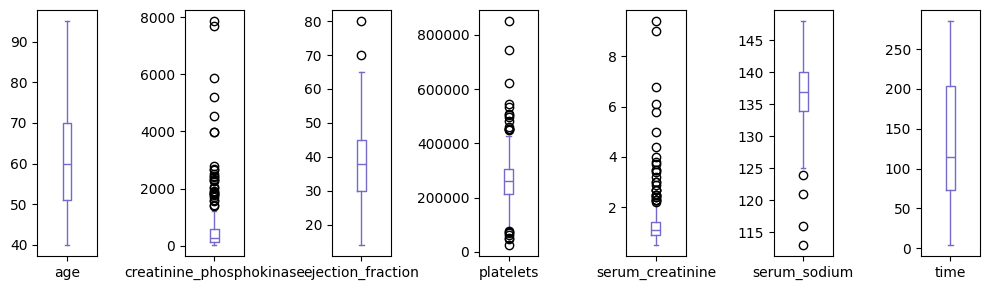

In [ ]:
#Visualize (without binary variables and outcome)
description = df.drop(columns=['anaemia', 'diabetes', 'hypertension', 'sex','smoking', 'hf_mortality'])

description.plot(kind='box', subplots=True, layout=(1, 7), figsize=(10, 3), color='#7569c9')
plt.tight_layout()
plt.show()

Boxplot observations:


*   Multiple variables appear to have datapoints outside their 1.5x interquartile range that may considered outliers
*   Creatinine_phosphokinase and serum_creatinine have similar absolute distributions and many potential outliers







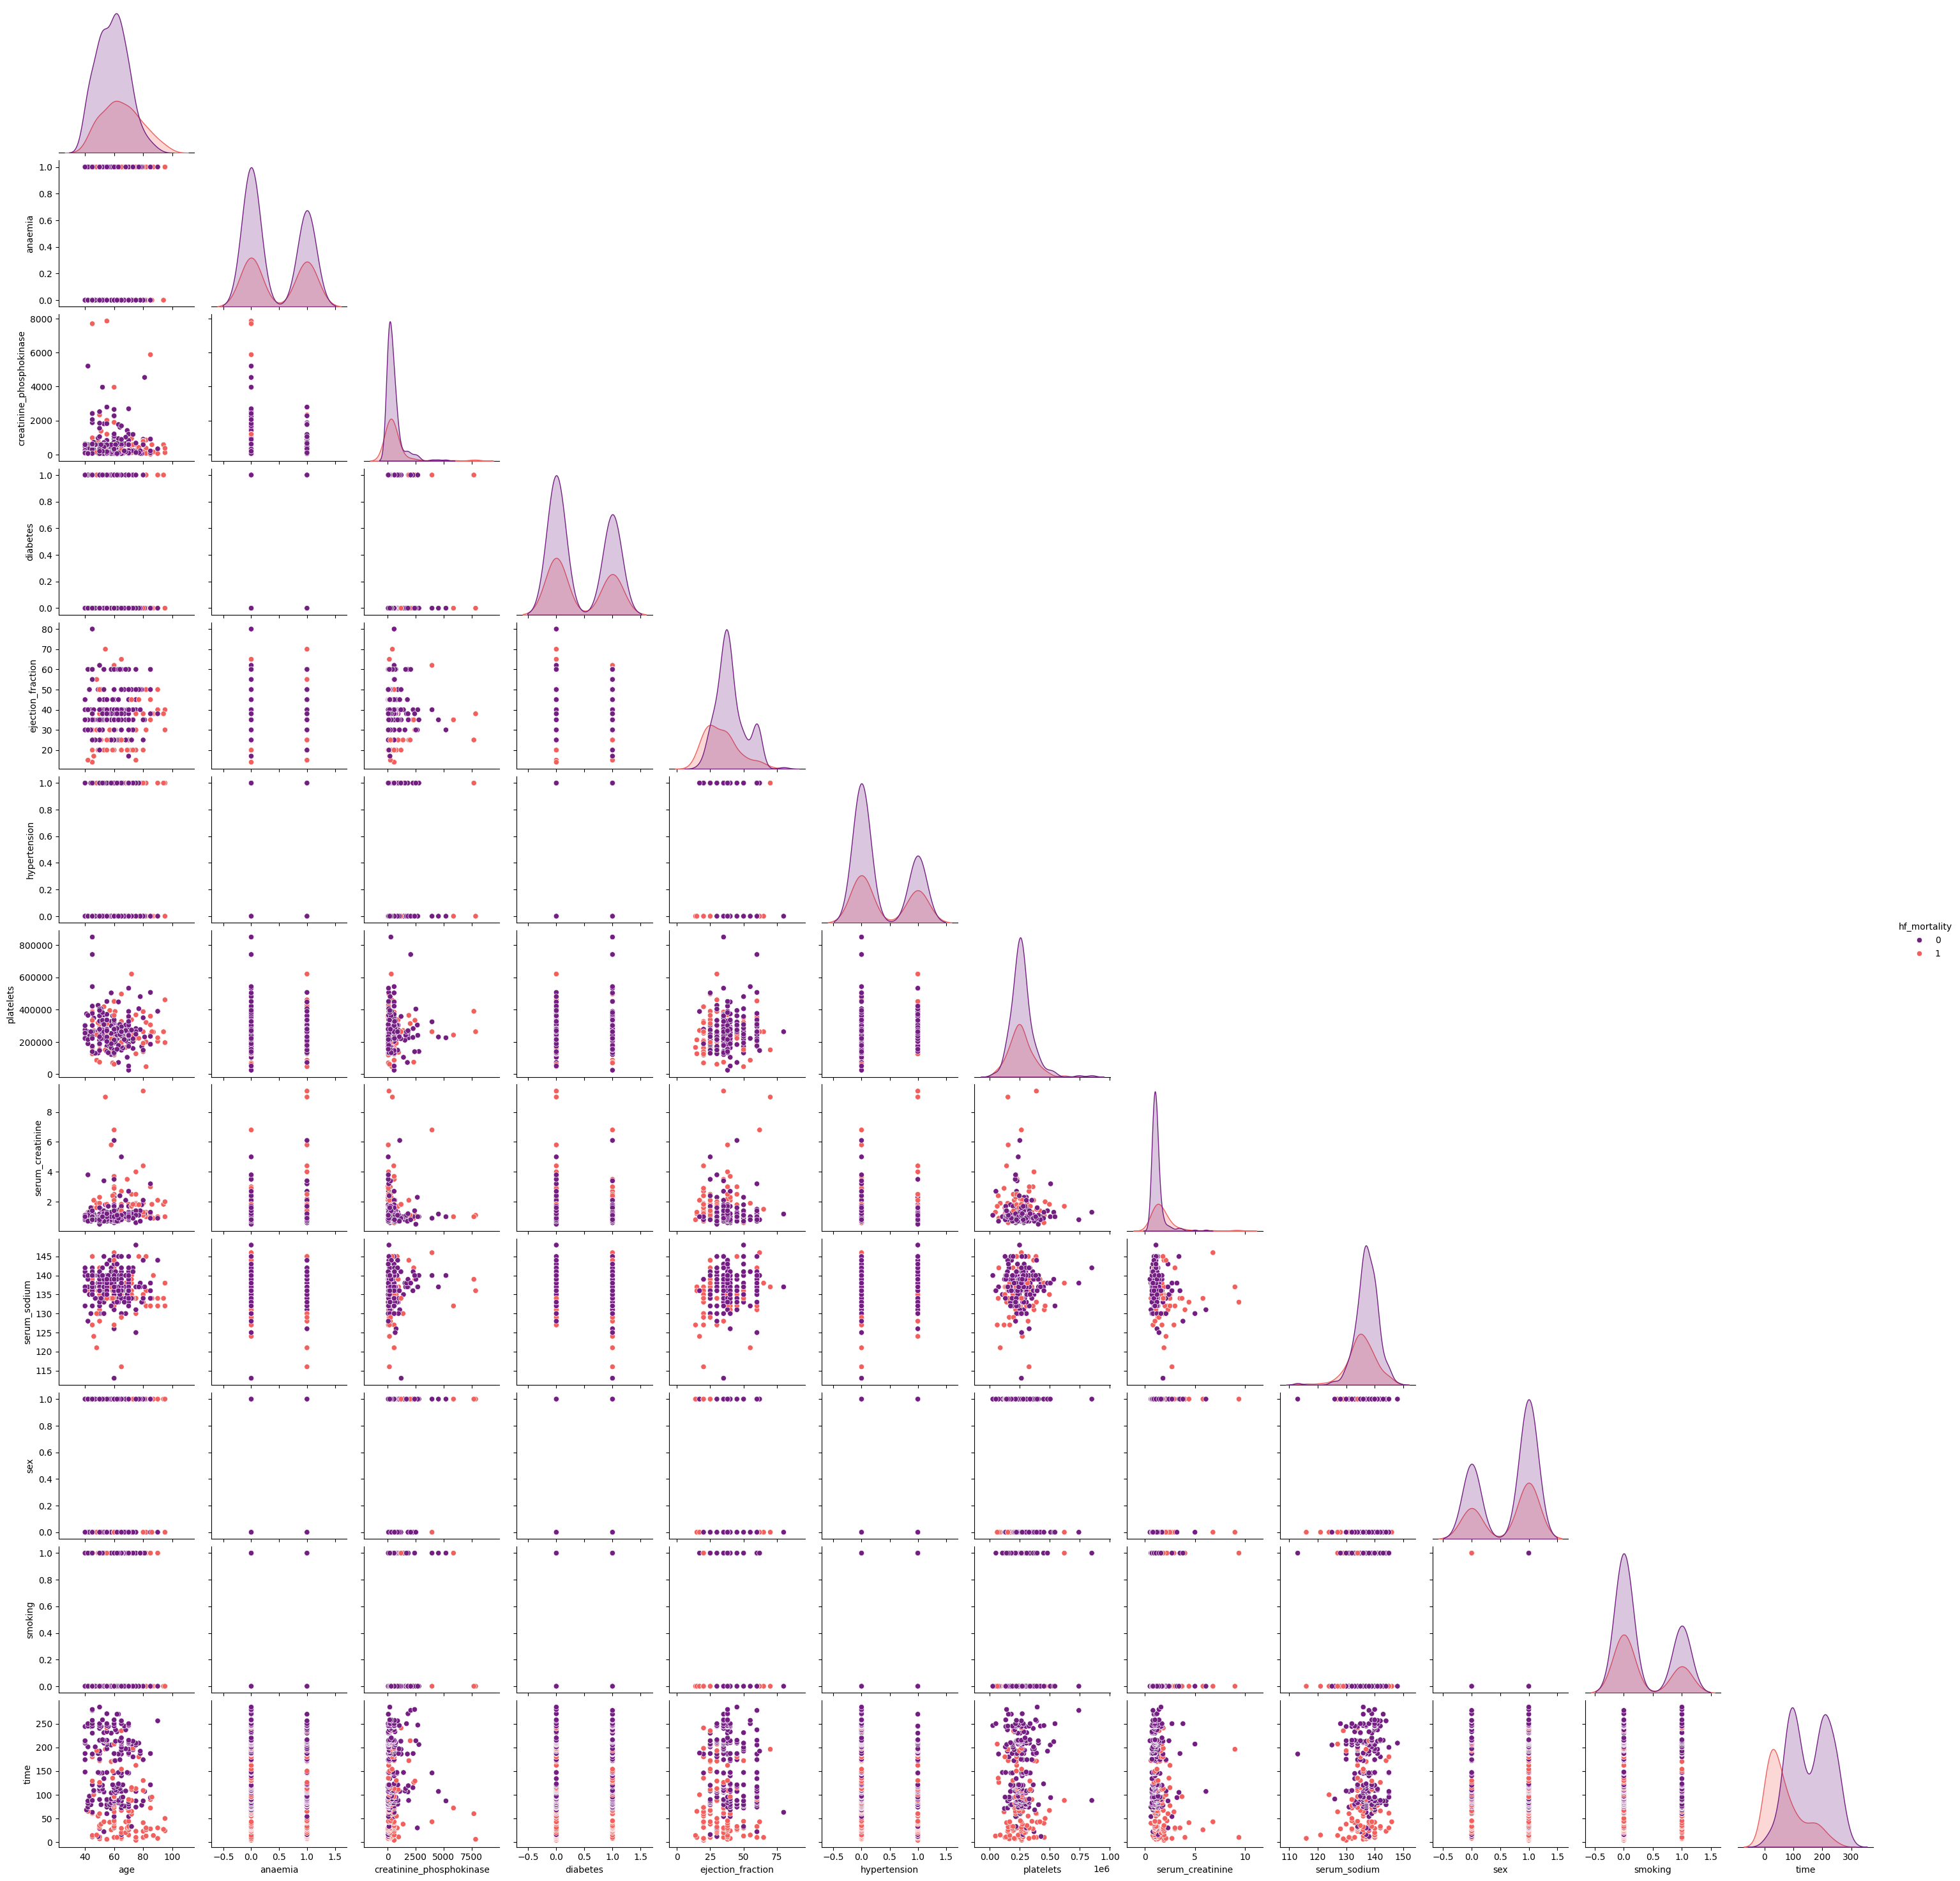

In [ ]:
#Display pair plot for data visualization
df_plot = df.drop(columns=['time'])
sns.pairplot(df, hue='hf_mortality', palette="magma", corner=True)
plt.show()



In [ ]:
#Find missing values
print("All missing values:")
print(df.isnull().sum())

#Find duplicates
duplicates = df[df.duplicated(keep=False)]

print("All duplicate rows:")
print(duplicates)

#Find outliers for creatine_phosphokinase
q1 = df['creatinine_phosphokinase'].quantile(0.25)
q3 = df['creatinine_phosphokinase'].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 3 * iqr
upper_bound = q3 + 3 * iqr
outliers = df[(df['creatinine_phosphokinase'] < lower_bound) | (df['creatinine_phosphokinase'] > upper_bound)]

print("Outliers for creatine_phosphokinase using IQR method:")
print(outliers.shape)

#Find outliers for ejection_fraction
q1 = df['ejection_fraction'].quantile(0.25)
q3 = df['ejection_fraction'].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 3 * iqr
upper_bound = q3 + 3 * iqr
outliers = df[(df['ejection_fraction'] < lower_bound) | (df['ejection_fraction'] > upper_bound)]

print("Outliers for ejection_fraction using IQR method:")
print(outliers.shape)

#Find outliers for serum_creatinine
q1 = df['serum_creatinine'].quantile(0.25)
q3 = df['serum_creatinine'].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 3 * iqr
upper_bound = q3 + 3 * iqr
outliers = df[(df['serum_creatinine'] < lower_bound) | (df['serum_creatinine'] > upper_bound)]

print("Outliers for serum_creatinine using IQR method:")
print(outliers.shape)

#Find outliers for platelets
q1 = df['platelets'].quantile(0.25)
q3 = df['platelets'].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 3 * iqr
upper_bound = q3 + 3 * iqr
outliers = df[(df['platelets'] < lower_bound) | (df['platelets'] > upper_bound)]

print("Outliers for platelets using IQR method:")
print(outliers.shape)

df_clean = df[(df['platelets'] >= lower_bound) & (df['platelets'] <= upper_bound)]
print("Size of dataset with outliers removed:")
print(df_clean.shape)

#Find outliers for serum_sodium
q1 = df_clean['serum_sodium'].quantile(0.25)
q3 = df_clean['serum_sodium'].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 3 * iqr
upper_bound = q3 + 3 * iqr
outliers = df_clean[(df['serum_sodium'] < lower_bound) | (df_clean['serum_sodium'] > upper_bound)]

print("Outliers for serum_sodium using IQR method:")
print(outliers.shape)

All missing values:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
hypertension                0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
hf_mortality                0
dtype: int64
All duplicate rows:
Empty DataFrame
Columns: [age, anaemia, creatinine_phosphokinase, diabetes, ejection_fraction, hypertension, platelets, serum_creatinine, serum_sodium, sex, smoking, time, hf_mortality]
Index: []
Outliers for creatine_phosphokinase using IQR method:
(18, 13)
Outliers for ejection_fraction using IQR method:
(0, 13)
Outliers for serum_creatinine using IQR method:
(17, 13)
Outliers for platelets using IQR method:
(3, 13)
Size of dataset with outliers removed:
(296, 13)
Outliers for serum_sodium using IQR method:
(1, 13)


Observations:


*   No missing or duplicate values were found so no rows were removed
*   Interquartile method selected for elimination of duplicates because data may be skewed per visualizations, whereas z-score method requires normal distribution
*   High interquartile range multipliers was used (3) to find extreme outliers for variables with large spread
*   A conservative approach to removing outliers was taken due to the small size of the dataset
*   4 extreme outliers were removed reducing the dataset from 299 cases to 295
*   Outliers were not removed from the creatinine phosphokinase and serum creatinine variables because they were believed to have clinical significance












In [ ]:
#Check for class imbalance
class_counts = df_clean['hf_mortality'].value_counts()
class_percentages = df_clean['hf_mortality'].value_counts(normalize=True) * 100
print(class_counts)
print(class_percentages)

hf_mortality
0    201
1     95
Name: count, dtype: int64
hf_mortality
0    67.905405
1    32.094595
Name: proportion, dtype: float64


Observations:

There is a class imbalance: 68% of the dataset cases do not have heart failure, this may lead to overfitting in that population

In [ ]:
#Split the data into features and target variable
#Remove outcome from features used for prediction
X = df_clean.drop('hf_mortality', axis=1)
#Assign prediction outcome
y = df_clean['hf_mortality']

#Split the data into training and testing sets
##check validity of split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Normalize training and testing sets
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
#Training logistic regression model
log_reg = LogisticRegression(penalty='l2', C=1.0, solver='liblinear')
log_reg.fit(X_train, y_train)


LogisticRegression(solver='liblinear')

In [ ]:
#Use the model to make predictions on the testing data
y_pred = log_reg.predict(X_test)

#Evaluate the model
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print("Confusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)


Confusion Matrix:
[[31  5]
 [ 7 17]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.86      0.84        36
           1       0.77      0.71      0.74        24

    accuracy                           0.80        60
   macro avg       0.79      0.78      0.79        60
weighted avg       0.80      0.80      0.80        60



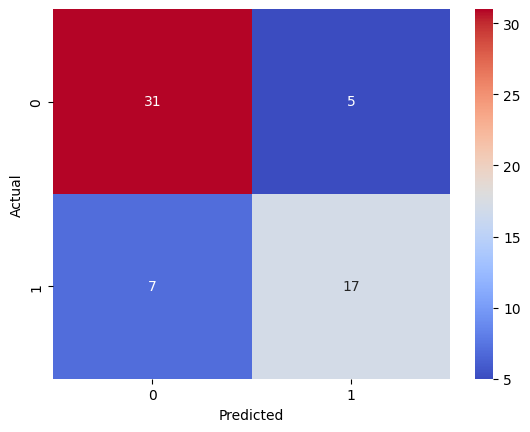

In [ ]:
#Visualize the confusion matrix
sns.heatmap(conf_matrix, cmap='coolwarm', annot=True, fmt='d')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

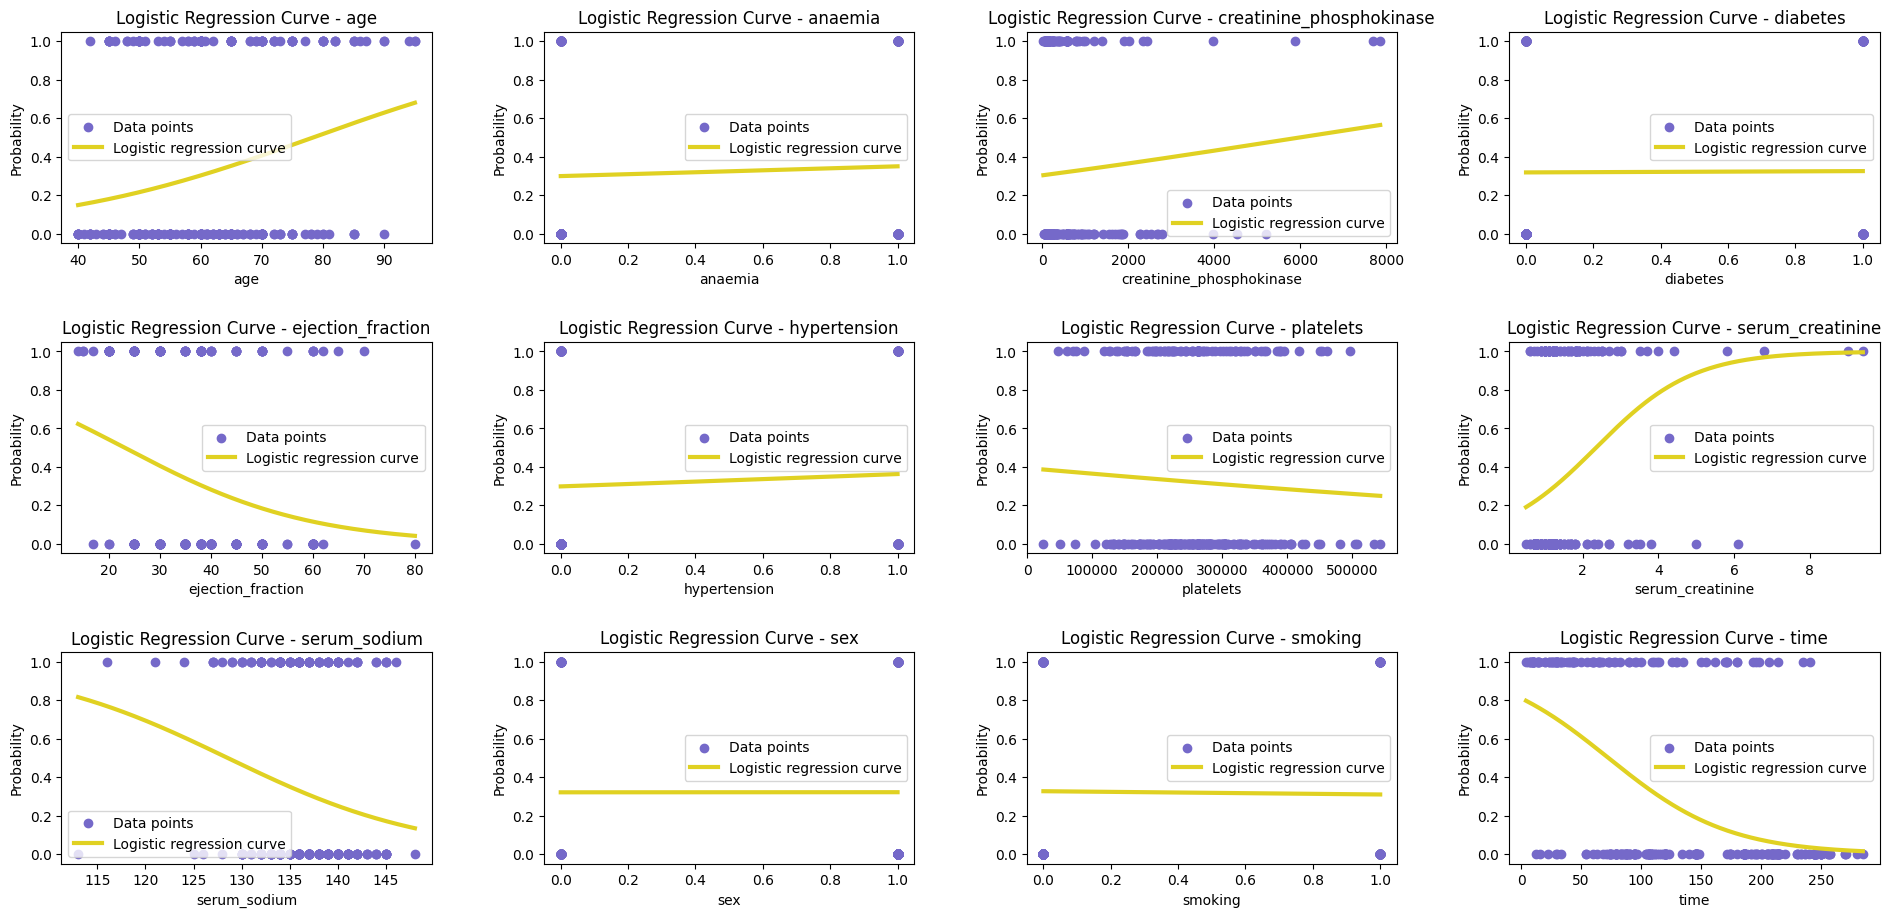

In [ ]:
#Create logistic regression object
log_reg = LogisticRegression()

# Calculate the number of features to plot
num_features = len(df.columns[:-1])
# Determine the number of rows needed for the subplots
# If there are 12 features, and 4 columns per row, then 3 rows are needed (12 / 4 = 3)
num_rows = (num_features + 3) // 4 # (num_features + num_cols - 1) // num_cols to round up

fig, axs = plt.subplots(num_rows, 4, figsize=(20, 10))
fig.tight_layout(pad=5.0)  # Adds padding between subplots

for i, feature in enumerate(df.columns[:-1]):  # Exclude 'hf_mortality' column
    row = i // 4  # Determine row index
    col = i % 4   # Determine column index

    #Reshape the feature and outcome arrays to fit the model
    X = df_clean[[feature]]
    y = df_clean['hf_mortality']

    #Fit logistic regression model
    log_reg.fit(X, y)

    #Get min and max values of the feature for plotting
    x_test = np.linspace(X.min(), X.max(), 300)

    #Get the probability for each value in the range
    prob = log_reg.predict_proba(x_test)[:, 1]

    #Plot the data points
    axs[row, col].scatter(X, y, color='#7569c9', label='Data points')

    #Plot the sigmoid curve
    axs[row, col].plot(x_test, prob, color='#e0d122', lw=3, label='Logistic regression curve' )

    axs[row, col].set_title(f'Logistic Regression Curve - {feature}')
    axs[row, col].set_xlabel(feature)
    axs[row, col].set_ylabel('Probability')
    axs[row, col].legend()

# Hide any unused subplots if the number of features is not a multiple of 4
for i in range(num_features, num_rows * 4):
    row = i // 4
    col = i % 4
    fig.delaxes(axs[row, col])

plt.show()

In [ ]:
import statsmodels.api as sm

#Separate features and target variable
###Do we need to redo this?
X = df_clean.drop('hf_mortality', axis=1)
y = df_clean['hf_mortality']

#Add a constant term for the intercept
X = sm.add_constant(X)

#Create and fit logistic regression model
log_reg = sm.Logit(y, X).fit()

#Get summary report
summary = log_reg.summary()
print(summary)

Optimization terminated successfully.
         Current function value: 0.368823
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:           hf_mortality   No. Observations:                  296
Model:                          Logit   Df Residuals:                      283
Method:                           MLE   Df Model:                           12
Date:                Wed, 28 Jan 2026   Pseudo R-squ.:                  0.4123
Time:                        15:23:20   Log-Likelihood:                -109.17
converged:                       True   LL-Null:                       -185.76
Covariance Type:            nonrobust   LLR p-value:                 1.280e-26
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       10.1907      5.683      1.793      0.073      -0.949

Test weighted model to account for class imbalance

In [ ]:
#Fit a weighted logistic regression model
weights = {0: 1, 1: 10}  #Higher weight for class 1 (minority class)
weighted_lr_model = LogisticRegression(random_state=42, class_weight=weights)
weighted_lr_model.fit(X_train, y_train)

# Make predictions with the weighted model
y_pred_weighted_lr = weighted_lr_model.predict(X_test)

# Evaluate the weighted model
print('Weighted Logistic Regression:')
print(classification_report(y_test, y_pred_weighted_lr))

Weighted Logistic Regression:
              precision    recall  f1-score   support

           0       0.90      0.53      0.67        36
           1       0.56      0.92      0.70        24

    accuracy                           0.68        60
   macro avg       0.73      0.72      0.68        60
weighted avg       0.77      0.68      0.68        60



<font color='#2a9d8f' size=5> Compare with KNN </font>



[[38  0]
 [14  7]]
              precision    recall  f1-score   support

           0       0.73      1.00      0.84        38
           1       1.00      0.33      0.50        21

    accuracy                           0.76        59
   macro avg       0.87      0.67      0.67        59
weighted avg       0.83      0.76      0.72        59



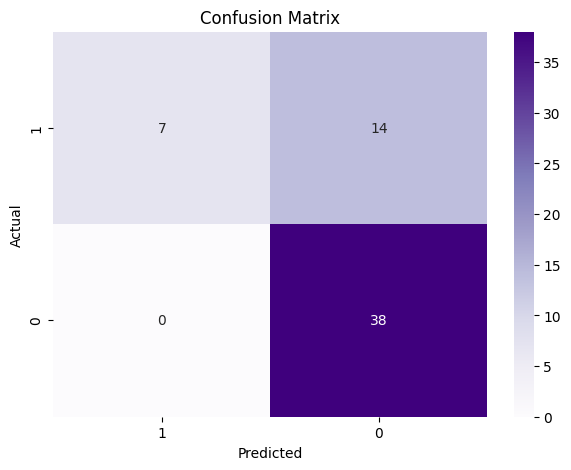

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.neighbors import KNeighborsClassifier



knn = KNeighborsClassifier(n_neighbors=5)  # Setting K to 5 as an example
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

import seaborn as sns
import matplotlib.pyplot as plt

# Get unique classes
classes = df_clean['hf_mortality'].unique()

# Plotting the confusion matrix
plt.figure(figsize=(7,5))
sns.heatmap(confusion_matrix(y_test, y_pred, labels=classes), cmap='Purples', annot=True, fmt='g', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


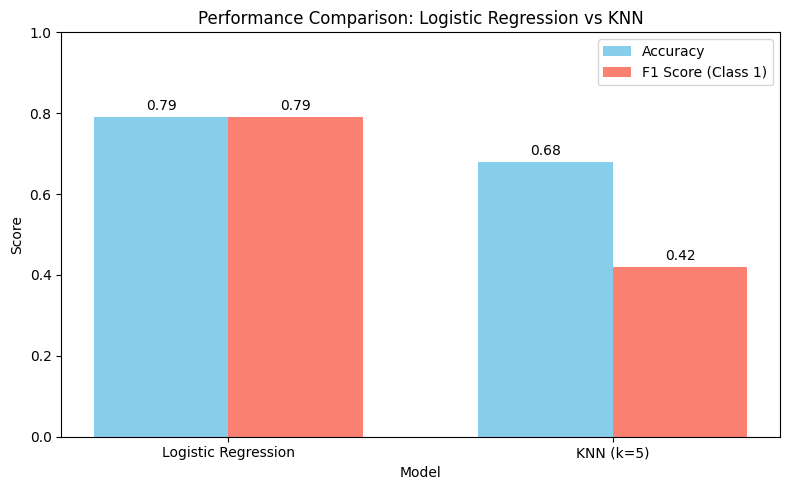

In [ ]:
# Compare the performance of KNN and logistic model

import matplotlib.pyplot as plt
import numpy as np


# model's name
test_ks = ['Logistic Regression', 'KNN (k=5)']

# ）
accuracy = [0.79, 0.68]
f1 = [0.79, 0.42]   # class 1 的 F1-score

x = np.arange(len(test_ks))
width = 0.35

fig, ax = plt.subplots(figsize=(8,5))

# create two columns
rects1 = ax.bar(x - width/2, accuracy, width,
                label='Accuracy', color='skyblue')
rects2 = ax.bar(x + width/2, f1, width,
                label='F1 Score (Class 1)', color='salmon')

# labels and title
ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Performance Comparison: Logistic Regression vs KNN')
ax.set_xticks(x)
ax.set_xticklabels(test_ks)
ax.legend()

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width()/2, height),
                    xytext=(0,3),
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.ylim(0, 1.0)
plt.tight_layout()
plt.show()


